Использовал я эти скрипты для того что бы сделать более читаемыми логи из Wireshark. Как только вы сохранили логи для обоих устройств в блокноты или во что то подобное нужно запустить первый скрипт для каждого из этих файлов, этот скрипт просто добавляет название вашего устройства перед каждой командной или ответом от этого устройства. Далее необходимо запустить 2-ой скрипт он уберет дельту времени отправки команд и ответов на них, и вместо дельты напишет временную точку отправки. После этого логи уже читаемы но можно так же загрузить в скрипт для разделения по блокам команд, что бы устройство1 от устройства2 отделены были пустой строкой. Все скрипты подписанны, так что думаю понятно)


In [6]:
from google.colab import files
import io
"""
Этот скрипт мы используем что бы записать дельту времени в одну строку с командой и добавить устройство которому мы отправляем команду или которое отвечает нам
"""
def process_log_data(content): #Преобразуем дельту в логах, в временную точку отправки SCPI команды
    instrument = input("Введите что хотите указывать в начале строки")
    total_time = 0.0
    output_lines = []

    for line in content.splitlines():
        original_line = line
        stripped = line.strip()

        if not stripped:# Пустые строки оставляем как есть
            output_lines.append(original_line)
            continue

        if stripped.endswith('s'):# Если строка является дельтой (оканчивается на 's')
            try:
                delta = float(stripped[:-1])
                total_time += delta
                continue
            except ValueError:
                pass

        output_lines.append(f"{instrument} {total_time:.6f}s {original_line}")# Всё остальное (команды и ответы) выводим с временной меткой
    return "\n".join(output_lines)


uploaded = files.upload()# Загружаем файл с компьютера

for filename, file_bytes in uploaded.items():# Обрабатываем каждый загруженный файл (обычно один)
    file_content = file_bytes.decode('utf-8')# Декодируем байты в текст (предполагаем UTF-8)
    result = process_log_data(file_content)

    output_filename = "processed_" + filename
    with open(output_filename, "w", encoding="utf-8") as f:
        f.write(result)

    files.download(output_filename)# Скачиваем

Saving SN9000 to SN9000 (1)
Введите что хотите указывать в начале строкиSN9000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
from google.colab import files
import re
"""
Этот скрипт нужен для объединения 2 .txt файлов
"""
def parse_line(line):
    """
    Извлекает время (float) и остаток строки из строки вида "0.123456s текст".
    Возвращает (время, остаток) или None, если строка пустая или не соответствует формату.
    """
    line = line.rstrip('\n')
    if not line.strip():
        return None  # пропускаем пустые строки
    # Разделяем по первому пробелу
    parts = line.split(maxsplit=2)
    if len(parts) != 3:
        return None  # неверный формат
    instrument, time_part, rest = parts
    if not time_part.endswith('s'):
        return None
    try:
        t = float(time_part[:-1])
    except ValueError:
        return None
    return (t, rest)

def merge_logs():
    """
    Загружает два файла, объединяет их строки с временными метками,
    сортирует по времени и возвращает объединённый текст.
    """
    print("Загрузите первый файл с временными метками")
    uploaded1 = files.upload()
    if not uploaded1:
        print("Первый файл не загружен.")
        return
    filename1 = list(uploaded1.keys())[0]
    content1 = uploaded1[filename1].decode('utf-8').splitlines()

    print("Загрузите второй файл с временными метками")
    uploaded2 = files.upload()
    if not uploaded2:
        print("Второй файл не загружен.")
        return
    filename2 = list(uploaded2.keys())[0]
    content2 = uploaded2[filename2].decode('utf-8').splitlines()

    # Собираем все события (время, полная исходная строка) из обоих файлов
    events = []

    for line in content1:
        parsed = parse_line(line)
        if parsed:
            t, rest = parsed
            events.append((t, line))  # сохраняем оригинальную строку целиком

    for line in content2:
        parsed = parse_line(line)
        if parsed:
            t, rest = parsed
            events.append((t, line))

    # Сортируем по времени. При одинаковом времени сохраняется порядок добавления
    # (сначала из первого файла, потом из второго)
    events.sort(key=lambda x: x[0])

    # Формируем результат
    result = '\n'.join(line for _, line in events)

    # Сохраняем в файл
    output_filename = "merged_log.txt"
    with open(output_filename, "w", encoding="utf-8") as f:
        f.write(result)

    # Скачиваем
    files.download(output_filename)
    print(f"Готово! Объединённый файл '{output_filename}' скачан.")

if __name__ == "__main__":
    merge_logs()

Загрузите первый файл с временными метками


Saving processed_Obzor804 (1) (1) to processed_Obzor804 (1) (1)
Загрузите второй файл с временными метками


Saving processed_SN9000 (1) to processed_SN9000 (1) (1)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Готово! Объединённый файл 'merged_log.txt' скачан.


In [ ]:
from google.colab import files
import io
"""
Этот скрипт нужен для того что бы вынести одного интересуещего наш значения, например все значения котрые мы задаём с помощью SOURce1:POWer
"""
def process_log_data(content):
    command = input("Введите после какой команды вы хотите вынести значения ")
    total_time = 0.0
    output_lines = []

    for line in content.splitlines():
        original_line = line
        splited = line.split()

        if not splited:
            continue
        else:
          for i in range(len(splited) - 1):
            if splited[i] == command:
              output_lines.append(splited[i+1])
              break

    return "\n".join(output_lines)

uploaded = files.upload()

for filename, file_bytes in uploaded.items():
    print(f"Обрабатывается файл: {filename}")
    file_content = file_bytes.decode('utf-8')

    result = process_log_data(file_content)

    output_filename = "processed_" + filename
    with open(output_filename, "w", encoding="utf-8") as f:
        f.write(result)

    files.download(output_filename)

    print(f"Результат сохранён в {output_filename} и скачан.")

Saving splited_merged_ADC_start_R1_R2.txt to splited_merged_ADC_start_R1_R2 (1).txt
Обрабатывается файл: splited_merged_ADC_start_R1_R2 (1).txt
Введите после какой команды вы хотите вынести значения SOURce1:POWer


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Результат сохранён в processed_splited_merged_ADC_start_R1_R2 (1).txt и скачан.


In [ ]:
from google.colab import files
import io
"""
Этот скрипт нужен для того что бы разделить по блокам команды генератора от команд устройства
"""
def process_log_data(content):
    name_before = "SN9000-10"
    output_lines = []

    for line in content.splitlines():
        original_line = line
        splited = line.split()

        if not splited:
            output_lines.append(original_line)
            continue
        else:
          if splited[0] != name_before:
            name_before = splited[0]
            output_lines.append("")
            output_lines.append(original_line)
          else:
            output_lines.append(original_line)

    return "\n".join(output_lines)

uploaded = files.upload()

for filename, file_bytes in uploaded.items():
    print(f"Обрабатывается файл: {filename}")
    file_content = file_bytes.decode('utf-8')

    result = process_log_data(file_content)

    output_filename = "processed_" + filename
    with open(output_filename, "w", encoding="utf-8") as f:
        f.write(result)

    files.download(output_filename)

    print(f"Результат сохранён в {output_filename} и скачан.")

Saving merged_log.txt to merged_log (2).txt
Обрабатывается файл: merged_log (2).txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Результат сохранён в processed_merged_log (2).txt и скачан.


In [ ]:
from google.colab import files
import io
"""
Этот скрипт собирает все значения которые нам отправляют устройства, в ответ на определенную команду
"""
def process_log_data(content):
    command = input("Ввелите вопросительную команду после которой нужно собрать данные ")
    output_lines = []
    flag = False
    for line in content.splitlines():
        original_line = line
        splited = line.split()

        if not splited:
            output_lines.append(original_line)
            continue
        else:
          try:
            if splited[2] == command:
              output_lines.append(f"{line}")
          except:
            continue
    return "\n".join(output_lines)

uploaded = files.upload()

for filename, file_bytes in uploaded.items():
    print(f"Обрабатывается файл: {filename}")
    file_content = file_bytes.decode('utf-8')

    result = process_log_data(file_content)

    output_filename = "processed_" + filename
    with open(output_filename, "w", encoding="utf-8") as f:
        f.write(result)

    files.download(output_filename)

    print(f"Результат сохранён в {output_filename} и скачан.")

Saving merged_ADC_start_T1-R1_T2-R2.txt to merged_ADC_start_T1-R1_T2-R2 (1).txt
Обрабатывается файл: merged_ADC_start_T1-R1_T2-R2 (1).txt
Ввелите вопросительную команду после которой нужно собрать данные SENS:SEGM:DATA


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Результат сохранён в processed_merged_ADC_start_T1-R1_T2-R2 (1).txt и скачан.


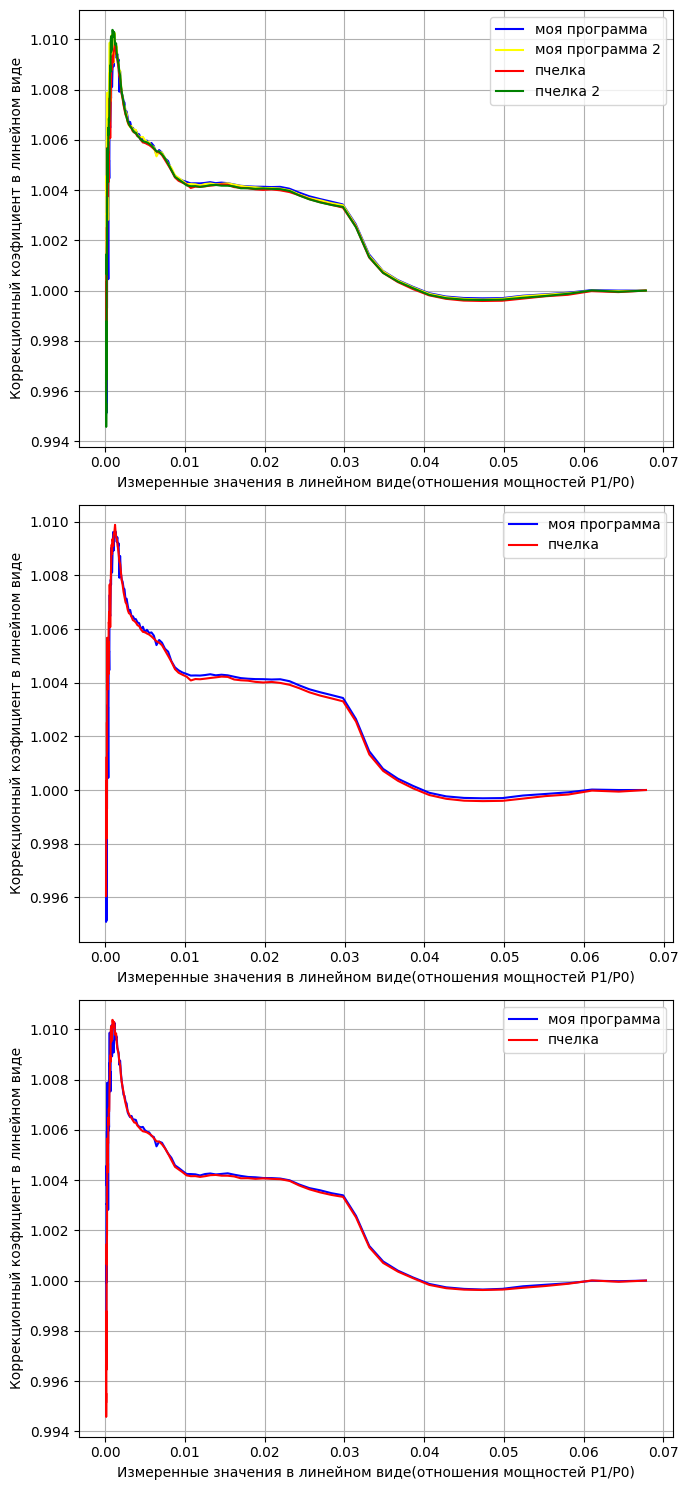

In [ ]:

import matplotlib.pyplot as plt
"""
Этот скрипт мы используем для сравнения коэфициентов которые мы получаем из нашей программы и пчелки
"""
def vizualization_all_pictures():
    my_program_1 = [6.774881E-02,1.000000E+00,6.434854E-02,9.999994E-01,6.097504E-02,1.000017E+00,5.800906E-02,9.999139E-01,5.511187E-02,9.998514E-01,5.234955E-02,9.997944E-01,4.977452E-02,9.996991E-01,4.730089E-02,9.996912E-01,4.495518E-02,9.997053E-01,4.271884E-02,9.997635E-01,4.060557E-02,9.998974E-01,3.858489E-02,1.000152E+00,3.668183E-02,1.000421E+00,3.482248E-02,1.000788E+00,3.308970E-02,1.001447E+00,3.142399E-02,1.002648E+00,2.980540E-02,1.003431E+00,2.834752E-02,1.003542E+00,2.693481E-02,1.003646E+00,2.558472E-02,1.003757E+00,2.431167E-02,1.003904E+00,2.311308E-02,1.004057E+00,2.194827E-02,1.004130E+00,2.086009E-02,1.004121E+00,1.981319E-02,1.004133E+00,1.882552E-02,1.004136E+00,1.790448E-02,1.004150E+00,1.699496E-02,1.004173E+00,1.616300E-02,1.004225E+00,1.536074E-02,1.004277E+00,1.458332E-02,1.004299E+00,1.386497E-02,1.004277E+00,1.317950E-02,1.004317E+00,1.251787E-02,1.004287E+00,1.189484E-02,1.004268E+00,1.131040E-02,1.004272E+00,1.073909E-02,1.004268E+00,1.020929E-02,1.004328E+00,9.704146E-03,1.004381E+00,9.212165E-03,1.004462E+00,8.756156E-03,1.004574E+00,8.310271E-03,1.004803E+00,7.901049E-03,1.005158E+00,7.506783E-03,1.005267E+00,7.126666E-03,1.005494E+00,6.775131E-03,1.005596E+00,6.441489E-03,1.005404E+00,6.112482E-03,1.005757E+00,5.810295E-03,1.005876E+00,5.523733E-03,1.005854E+00,5.243866E-03,1.005975E+00,4.985814E-03,1.005883E+00,4.736366E-03,1.006088E+00,4.500286E-03,1.005990E+00,4.275940E-03,1.006222E+00,4.060664E-03,1.006247E+00,3.859025E-03,1.006371E+00,3.668032E-03,1.006379E+00,3.482990E-03,1.006480E+00,3.309605E-03,1.006482E+00,3.147425E-03,1.006712E+00,2.987550E-03,1.006655E+00,2.839159E-03,1.006881E+00,2.698757E-03,1.007134E+00,2.561965E-03,1.007096E+00,2.434850E-03,1.007485E+00,2.313740E-03,1.007540E+00,2.197460E-03,1.007768E+00,2.088005E-03,1.007846E+00,1.984714E-03,1.008078E+00,1.883578E-03,1.008728E+00,1.791270E-03,1.007916E+00,1.698570E-03,1.009198E+00,1.614499E-03,1.009061E+00,1.534832E-03,1.009423E+00,1.457321E-03,1.009254E+00,1.385070E-03,1.009472E+00,1.316551E-03,1.009638E+00,1.249971E-03,1.009511E+00,1.188251E-03,1.009508E+00,1.129465E-03,1.009533E+00,1.073399E-03,1.008929E+00,1.019312E-03,1.009621E+00,9.694049E-04,1.009245E+00,9.211050E-04,1.008654E+00,8.760522E-04,1.008113E+00,8.308891E-04,1.008983E+00,7.898359E-04,1.009036E+00,7.520005E-04,1.007660E+00,7.133706E-04,1.007847E+00,6.791167E-04,1.006966E+00,6.456732E-04,1.006483E+00,6.131737E-04,1.006604E+00,5.823176E-04,1.007275E+00,5.541022E-04,1.006492E+00,5.271816E-04,1.004467E+00,5.005385E-04,1.005187E+00,4.761794E-04,1.005028E+00,4.521868E-04,1.004581E+00,4.306106E-04,1.003062E+00,4.102243E-04,1.000456E+00,3.894404E-04,1.001255E+00,3.694486E-04,1.003100E+00,3.508471E-04,1.002607E+00,3.334703E-04,1.003180E+00,3.171984E-04,1.001827E+00,3.013591E-04,1.001596E+00,2.859496E-04,1.003160E+00,2.722285E-04,1.002220E+00,2.583676E-04,1.002376E+00,2.461547E-04,9.993061E-01,2.340739E-04,9.992829E-01,2.225695E-04,9.986210E-01,2.120976E-04,9.961140E-01,2.010371E-04,9.986918E-01,1.909154E-04,9.988006E-01,1.817866E-04,9.967911E-01,1.728020E-04,9.966081E-01,1.645208E-04,9.951304E-01,1.556975E-04,9.990314E-01,1.481457E-04,9.966765E-01,1.408535E-04,9.966845E-01,1.339022E-04,9.967675E-01,1.273363E-04,9.950830E-01,1.209383E-04,9.961648E-01]
    my_program_2 = [6.782396E-02,1.000000E+00,6.442071E-02,9.999755E-01,6.104844E-02,9.999944E-01,5.808085E-02,9.998946E-01,5.518163E-02,9.998334E-01,5.241592E-02,9.997732E-01,4.983942E-02,9.996717E-01,4.736435E-02,9.996434E-01,4.501440E-02,9.996699E-01,4.277555E-02,9.997312E-01,4.065871E-02,9.998662E-01,3.863529E-02,1.000122E+00,3.672960E-02,1.000394E+00,3.486826E-02,1.000762E+00,3.313507E-02,1.001378E+00,3.146732E-02,1.002580E+00,2.984521E-02,1.003395E+00,2.838561E-02,1.003480E+00,2.697096E-02,1.003595E+00,2.561925E-02,1.003682E+00,2.434479E-02,1.003825E+00,2.314430E-02,1.003992E+00,2.197788E-02,1.004062E+00,2.088754E-02,1.004081E+00,1.983947E-02,1.004084E+00,1.884978E-02,1.004113E+00,1.792788E-02,1.004126E+00,1.701674E-02,1.004168E+00,1.618383E-02,1.004216E+00,1.538055E-02,1.004271E+00,1.460290E-02,1.004247E+00,1.388336E-02,1.004226E+00,1.319671E-02,1.004264E+00,1.253443E-02,1.004242E+00,1.191096E-02,1.004185E+00,1.132510E-02,1.004230E+00,1.075298E-02,1.004241E+00,1.022303E-02,1.004245E+00,9.716636E-03,1.004364E+00,9.223485E-03,1.004486E+00,8.767032E-03,1.004589E+00,8.320194E-03,1.004887E+00,7.911889E-03,1.005054E+00,7.516395E-03,1.005276E+00,7.135792E-03,1.005487E+00,6.784232E-03,1.005533E+00,6.450015E-03,1.005345E+00,6.120624E-03,1.005716E+00,5.818419E-03,1.005763E+00,5.530560E-03,1.005900E+00,5.250801E-03,1.005927E+00,4.991645E-03,1.005990E+00,4.742279E-03,1.006118E+00,4.505548E-03,1.006102E+00,4.281823E-03,1.006127E+00,4.066011E-03,1.006196E+00,3.863864E-03,1.006395E+00,3.672584E-03,1.006413E+00,3.487613E-03,1.006420E+00,3.313542E-03,1.006554E+00,3.152110E-03,1.006503E+00,2.991543E-03,1.006587E+00,2.843307E-03,1.006693E+00,2.702401E-03,1.007050E+00,2.565074E-03,1.007127E+00,2.438255E-03,1.007357E+00,2.317006E-03,1.007392E+00,2.200424E-03,1.007683E+00,2.090558E-03,1.007927E+00,1.986873E-03,1.008257E+00,1.885927E-03,1.008755E+00,1.792293E-03,1.008589E+00,1.700960E-03,1.009073E+00,1.616406E-03,1.009169E+00,1.537042E-03,1.009268E+00,1.458493E-03,1.009724E+00,1.386539E-03,1.009701E+00,1.318273E-03,1.009602E+00,1.251078E-03,1.009897E+00,1.188869E-03,1.010257E+00,1.130997E-03,1.009449E+00,1.074575E-03,1.009082E+00,1.020719E-03,1.009534E+00,9.704340E-04,1.009448E+00,9.215907E-04,1.009377E+00,8.764650E-04,1.008929E+00,8.309744E-04,1.010170E+00,7.903281E-04,1.009689E+00,7.513757E-04,1.009801E+00,7.130828E-04,1.009514E+00,6.796081E-04,1.007532E+00,6.453277E-04,1.008329E+00,6.132055E-04,1.007859E+00,5.815856E-04,1.009872E+00,5.536831E-04,1.008570E+00,5.257040E-04,1.008643E+00,5.007214E-04,1.006104E+00,4.760703E-04,1.006537E+00,4.521538E-04,1.005970E+00,4.291857E-04,1.007672E+00,4.086972E-04,1.005545E+00,3.893298E-04,1.002819E+00,3.693506E-04,1.004663E+00,3.506834E-04,1.004357E+00,3.330688E-04,1.005775E+00,3.157823E-04,1.007704E+00,2.998697E-04,1.007887E+00,2.855121E-04,1.006069E+00,2.721808E-04,1.003759E+00,2.583777E-04,1.003650E+00,2.454972E-04,1.003378E+00,2.328245E-04,1.005993E+00,2.217208E-04,1.003770E+00,2.106281E-04,1.004398E+00,2.001367E-04,1.004578E+00,1.903857E-04,1.003043E+00,1.808888E-04,1.003055E+00,1.720808E-04,1.002120E+00,1.639394E-04,9.999206E-01,1.556214E-04,1.000821E+00,1.481639E-04,9.981081E-01,1.410241E-04,9.968226E-01,1.338459E-04,9.986033E-01,1.270566E-04,9.986795E-01,1.209817E-04,9.972092E-01]
    bee_1 = [6.775406E-02,1E+00,6.43565E-02,9.999401E-01,6.098657E-02,9.999785E-01,5.802433E-02,9.998322E-01,5.512783E-02,9.99772E-01,5.236775E-02,9.996805E-01,4.979208E-02,9.995965E-01,4.731838E-02,9.995862E-01,4.49718E-02,9.996018E-01,4.273414E-02,9.996724E-01,4.061954E-02,9.998125E-01,3.859986E-02,1.00006E+00,3.669496E-02,1.000342E+00,3.483515E-02,1.000712E+00,3.310334E-02,1.001325E+00,3.143557E-02,1.002552E+00,2.981723E-02,1.003306E+00,2.835861E-02,1.003417E+00,2.694541E-02,1.003521E+00,2.559546E-02,1.003643E+00,2.432201E-02,1.003797E+00,2.312302E-02,1.003923E+00,2.195823E-02,1.003993E+00,2.086836E-02,1.00403E+00,1.982119E-02,1.00401E+00,1.883285E-02,1.004033E+00,1.79111E-02,1.004077E+00,1.700162E-02,1.004092E+00,1.616984E-02,1.004121E+00,1.536675E-02,1.004218E+00,1.458934E-02,1.004229E+00,1.387066E-02,1.004201E+00,1.318537E-02,1.004178E+00,1.252372E-02,1.004152E+00,1.190017E-02,1.00413E+00,1.131529E-02,1.004139E+00,1.074442E-02,1.004086E+00,1.021386E-02,1.004228E+00,9.708192E-03,1.004297E+00,9.215796E-03,1.004372E+00,8.759731E-03,1.004507E+00,8.313466E-03,1.004782E+00,7.905254E-03,1.004999E+00,7.510299E-03,1.005204E+00,7.130017E-03,1.0054E+00,6.778515E-03,1.005494E+00,6.443172E-03,1.005545E+00,6.115706E-03,1.005641E+00,5.813546E-03,1.005727E+00,5.526385E-03,1.005796E+00,5.246758E-03,1.005836E+00,4.987845E-03,1.005886E+00,4.739156E-03,1.005897E+00,4.502146E-03,1.005991E+00,4.278228E-03,1.00611E+00,4.062853E-03,1.006146E+00,3.861213E-03,1.006244E+00,3.669834E-03,1.006302E+00,3.485007E-03,1.006336E+00,3.311126E-03,1.00646E+00,3.149302E-03,1.006561E+00,2.989054E-03,1.006593E+00,2.840903E-03,1.006717E+00,2.700554E-03,1.006924E+00,2.563378E-03,1.007003E+00,2.436662E-03,1.007201E+00,2.315228E-03,1.007388E+00,2.198773E-03,1.007652E+00,2.08912E-03,1.007813E+00,1.985619E-03,1.008133E+00,1.885036E-03,1.008427E+00,1.791075E-03,1.008528E+00,1.700059E-03,1.008822E+00,1.615427E-03,1.009019E+00,1.535862E-03,1.009255E+00,1.457871E-03,1.009379E+00,1.385846E-03,1.009431E+00,1.317243E-03,1.009619E+00,1.250203E-03,1.009888E+00,1.188669E-03,1.00969E+00,1.130055E-03,1.009576E+00,1.073354E-03,1.009522E+00,1.02042E-03,1.009099E+00,9.698688E-04,1.009287E+00,9.209724E-04,1.009351E+00,8.759182E-04,1.0088E+00,8.311945E-04,1.009151E+00,7.904206E-04,1.008852E+00,7.519484E-04,1.008297E+00,7.138194E-04,1.007768E+00,6.794506E-04,1.007036E+00,6.463379E-04,1.006073E+00,6.133115E-04,1.006982E+00,5.824554E-04,1.007665E+00,5.54299E-04,1.006765E+00,5.265429E-04,1.006324E+00,5.001375E-04,1.006636E+00,4.759231E-04,1.006232E+00,4.517517E-04,1.006246E+00,4.303638E-04,1.004316E+00,4.089022E-04,1.004376E+00,3.88028E-04,1.005561E+00,3.690621E-04,1.004845E+00,3.505775E-04,1.004039E+00,3.334757E-04,1.003942E+00,3.168407E-04,1.003751E+00,3.005395E-04,1.005012E+00,2.856845E-04,1.004842E+00,2.714918E-04,1.005678E+00,2.584787E-04,1.002749E+00,2.458329E-04,1.001434E+00,2.335146E-04,1.002523E+00,2.223561E-04,1.000349E+00,2.111888E-04,1.001235E+00,2.009567E-04,9.999761E-01,1.911718E-04,9.982593E-01,1.816918E-04,9.981909E-01,1.724445E-04,9.994951E-01,1.638452E-04,9.999251E-01,1.556375E-04,1.00033E+00,1.478335E-04,9.997963E-01,1.407431E-04,9.982403E-01,1.339794E-04,9.970819E-01,1.273283E-04,9.960353E-01,1.210268E-04,9.963256E-01]
    bee_2 = [6.782451E-02,1E+00,6.442226E-02,9.999525E-01,6.104894E-02,1.000006E+00,5.80835E-02,9.998741E-01,5.51864E-02,9.997832E-01,5.242104E-02,9.997144E-01,4.984227E-02,9.996419E-01,4.736553E-02,9.996254E-01,4.501788E-02,9.996397E-01,4.277797E-02,9.996963E-01,4.066153E-02,9.998271E-01,3.863815E-02,1.000093E+00,3.673261E-02,1.000356E+00,3.48705E-02,1.000703E+00,3.313772E-02,1.001323E+00,3.146937E-02,1.002514E+00,2.984755E-02,1.003332E+00,2.838852E-02,1.00341E+00,2.697394E-02,1.003511E+00,2.562222E-02,1.003633E+00,2.434742E-02,1.003786E+00,2.314588E-02,1.003968E+00,2.197951E-02,1.004038E+00,2.088987E-02,1.004051E+00,1.984108E-02,1.004068E+00,1.885241E-02,1.004051E+00,1.792994E-02,1.004076E+00,1.701978E-02,1.004074E+00,1.618602E-02,1.004147E+00,1.538295E-02,1.004175E+00,1.460526E-02,1.004177E+00,1.388481E-02,1.004206E+00,1.319888E-02,1.004196E+00,1.253675E-02,1.004156E+00,1.191261E-02,1.004128E+00,1.13271E-02,1.004159E+00,1.075481E-02,1.004157E+00,1.022461E-02,1.004189E+00,9.717962E-03,1.004315E+00,9.22483E-03,1.004426E+00,8.768546E-03,1.004529E+00,8.321866E-03,1.004794E+00,7.912935E-03,1.005045E+00,7.51745E-03,1.005264E+00,7.137172E-03,1.005426E+00,6.785224E-03,1.005532E+00,6.449662E-03,1.005546E+00,6.121728E-03,1.005665E+00,5.819052E-03,1.005782E+00,5.531631E-03,1.005844E+00,5.251681E-03,1.0059E+00,4.992682E-03,1.005928E+00,4.743714E-03,1.005945E+00,4.506576E-03,1.006008E+00,4.282507E-03,1.006091E+00,4.06675E-03,1.006166E+00,3.864894E-03,1.006284E+00,3.673536E-03,1.00629E+00,3.48824E-03,1.006378E+00,3.314242E-03,1.006477E+00,3.15236E-03,1.00653E+00,2.991754E-03,1.006634E+00,2.843516E-03,1.006743E+00,2.703217E-03,1.006879E+00,2.565608E-03,1.007065E+00,2.438844E-03,1.00726E+00,2.31712E-03,1.007503E+00,2.200691E-03,1.007691E+00,2.090856E-03,1.007905E+00,1.987283E-03,1.008178E+00,1.886438E-03,1.008577E+00,1.792347E-03,1.00871E+00,1.701239E-03,1.009005E+00,1.616686E-03,1.009129E+00,1.537188E-03,1.009284E+00,1.459002E-03,1.009494E+00,1.386551E-03,1.009844E+00,1.318201E-03,1.009787E+00,1.251387E-03,1.009791E+00,1.18915E-03,1.010202E+00,1.130249E-03,1.010301E+00,1.073657E-03,1.010105E+00,1.020156E-03,1.010195E+00,9.696878E-04,1.010365E+00,9.208356E-04,1.010381E+00,8.759458E-04,1.009641E+00,8.313861E-04,1.009786E+00,7.905842E-04,1.009525E+00,7.512243E-04,1.010123E+00,7.128912E-04,1.009927E+00,6.789006E-04,1.008701E+00,6.450126E-04,1.008959E+00,6.128884E-04,1.008514E+00,5.828123E-04,1.007869E+00,5.542964E-04,1.007602E+00,5.267152E-04,1.00682E+00,5.00482E-04,1.006722E+00,4.759947E-04,1.006853E+00,4.520135E-04,1.006399E+00,4.298924E-04,1.006192E+00,4.083633E-04,1.006481E+00,3.883521E-04,1.005466E+00,3.690954E-04,1.005486E+00,3.505064E-04,1.004975E+00,3.335935E-04,1.004311E+00,3.164925E-04,1.005534E+00,3.009595E-04,1.00431E+00,2.856342E-04,1.005659E+00,2.721142E-04,1.004065E+00,2.584073E-04,1.00365E+00,2.458841E-04,1.001842E+00,2.338335E-04,1.001692E+00,2.223662E-04,1.000906E+00,2.114323E-04,1.000641E+00,2.007673E-04,1.00146E+00,1.913464E-04,9.979089E-01,1.819718E-04,9.972374E-01,1.730764E-04,9.964514E-01,1.641396E-04,9.987819E-01,1.564639E-04,9.954535E-01,1.486252E-04,9.949176E-01,1.413603E-04,9.94574E-01,1.342592E-04,9.955153E-01,1.275192E-04,9.951358E-01,1.210576E-04,9.966224E-01]
    num_rows = 3
    num_cols = 1
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(7 * num_cols, 5 * num_rows))
    for i in range(len(axs)):
        current_num_of_picture = i
        if current_num_of_picture < 1:
            graphic_quatro(my_program_1, my_program_2, bee_1, bee_2, axs[i])
        elif current_num_of_picture == 1:
            graphic_solo(my_program_1, bee_1, axs[i])
        else:
            graphic_solo(my_program_2, bee_2, axs[i])
    plt.tight_layout()
    plt.show()

def graphic_solo(x, y, ax):
  ax.plot(x[::2], x[1::2], color = 'blue')
  ax.plot(y[::2], y[1::2], color = 'red')
  ax.set_xlabel("Измеренные значения в линейном виде(отношения мощностей P1/P0)")
  ax.set_ylabel("Коррекционный коэфициент в линейном виде")
  ax.grid(True)
  ax.legend(["моя программа", "пчелка"])

def graphic_quatro(x, x1, y, y1, ax):
  ax.plot(x[::2], x[1::2], color = 'blue')
  ax.plot(x1[::2], x1[1::2], color = 'yellow')
  ax.plot(y[::2], y[1::2], color = 'red')
  ax.plot(y1[::2], y1[1::2], color = 'green')
  ax.set_xlabel("Измеренные значения в линейном виде(отношения мощностей P1/P0)")
  ax.set_ylabel("Коррекционный коэфициент в линейном виде")
  ax.grid(True)
  ax.legend(["моя программа", "моя программа 2", "пчелка", "пчелка 2"])

vizualization_all_pictures()